In [7]:
import numpy as np
import torch
from model import FullModelHAT
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display
import ipywidgets as widgets


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1 = FullModelHAT(num_classes=11).to(device)
checkpoint1 = "rescuenet_seg_V13.pth"
ckpt = torch.load(checkpoint1, map_location=device)
model1.load_state_dict(ckpt['model_state'])
print("Loaded Model: ", checkpoint1)


image_size = (384, 384)

CLASS_NAMES = {
        0: 'Background',
        1: 'Water',
        2: 'Building_No_Damage',
        3: 'Building_Minor_Damage',
        4: 'Building_Major_Damage',
        5: 'Building_Total_Destruction',
        6: 'Vehicle',
        7: 'Road-Clear',
        8: 'Road-Blocked',
        9: 'Tree',
        10: 'Pool'
    }

CLASS_COLORS = np.array([
    [0, 0, 0],        # Background

    [40, 120, 200],   # Water → blue

    [200, 200, 210],  # Building_No_Damage → light cool gray
    [255, 230, 80],   # Building_Minor_Damage → yellow
    [255, 150, 40],   # Building_Major_Damage → orange
    [220, 40, 40],    # Building_Total_Destruction → red

    [120, 60, 200],   # Vehicle → purple (NOT green anymore)

    [60, 60, 60],     # Road-Clear → dark gray
    [170, 90, 30],    # Road-Blocked → strong brown (far from gray)

    [20, 160, 60],    # Tree → green (clearly different from vehicle now)

    [0, 200, 200]     # Pool → cyan (not same as water)
], dtype=np.uint8)



def mask_to_color(mask):
    return CLASS_COLORS[mask]

def image_to_tensor(image):
        img_np     = np.array(image)
        img_tensor = torch.from_numpy(img_np)
        img_tensor = img_tensor.permute(2, 0, 1)
        img_tensor = img_tensor.float() / 255.0

        # --- NORMALIZATION (add this) ---
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

        img_tensor = (img_tensor - mean) / std
        return img_tensor

def preprocessing(image_path):
    image = Image.open(image_path).convert('RGB')
    image = image.resize(image_size, Image.LANCZOS)
    return image_to_tensor(image).unsqueeze(0)


def denormalization(image):
    mean = torch.tensor([0.485, 0.456, 0.406], device=image.device).view(1,3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=image.device).view(1,3,1,1)

    return image * std + mean

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def show_image_and_overlay(image, overlay, pred_mask):
    plt.figure(figsize=(12,5))

    # ---- Image ----
    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis("off")

    # ---- Overlay ----
    ax = plt.subplot(1,2,2)
    ax.imshow(overlay)
    ax.set_title("Overlay")
    ax.axis("off")

    # ---- Legend ----
    unique_classes = np.unique(pred_mask)

    patches = []
    for cls in unique_classes:
        if cls == 0:
            continue  # skip background (optional)

        color = CLASS_COLORS[cls] / 255.0
        label = CLASS_NAMES.get(cls, f"Class {cls}")

        patches.append(mpatches.Patch(color=color, label=label))

    ax.legend(
        handles=patches,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8
        # facecolor='black', labelcolor='white'
    )

    plt.tight_layout()
    plt.show()


def inference(model, image_path):
    model.eval()

    image = preprocessing(image_path).to(device)
    with torch.no_grad():
        mask = model1(image)[0]

    image = denormalization(image)
    # mask = torch.softmax(mask, dim=1)
    mask = torch.argmax(mask, dim=1)

    image_vis = image[0].permute(1,2,0).cpu().numpy()  # (H,W,3)
    pred_mask = mask[0].cpu().numpy()


    color_mask = mask_to_color(pred_mask)   # (H,W,3), uint8

    # ---- overlay ----
    overlay = image_vis.copy()

    overlay[pred_mask != 0] = (
        0.3 * image_vis[pred_mask != 0] +
        0.7 * (color_mask[pred_mask != 0] / 255.0)
    )


    show_image_and_overlay(image_vis, overlay, pred_mask)

    return (overlay * 255).astype(np.uint8)

Loaded Model:  rescuenet_seg_V13.pth


In [29]:
import os

path = "./examples/"


print("For checking the inference, you can also choose some of the images from examples folder. Thank you :)")
os.listdir(path)

For checking the inference, you can also choose some of the images from examples folder. Thank you :)


['16320.jpg',
 '16331.jpg',
 '16498.jpg',
 '20419.jpg',
 '20427.jpg',
 '20435.jpg',
 'new-after.png',
 'new-before.png']

In [9]:
image_path = os.path.join(path, "new-before.png")
image_path2 = os.path.join(path, "new-after.png")

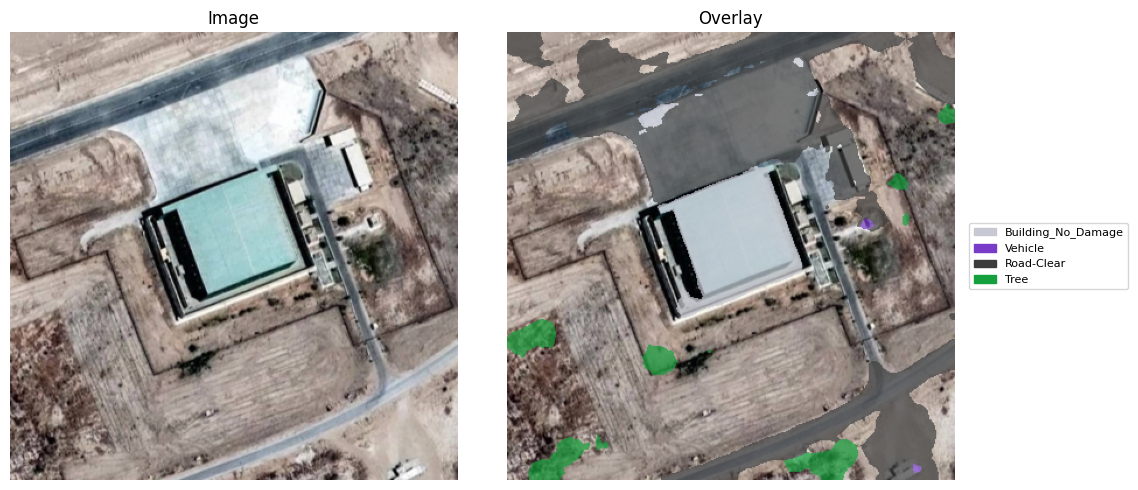

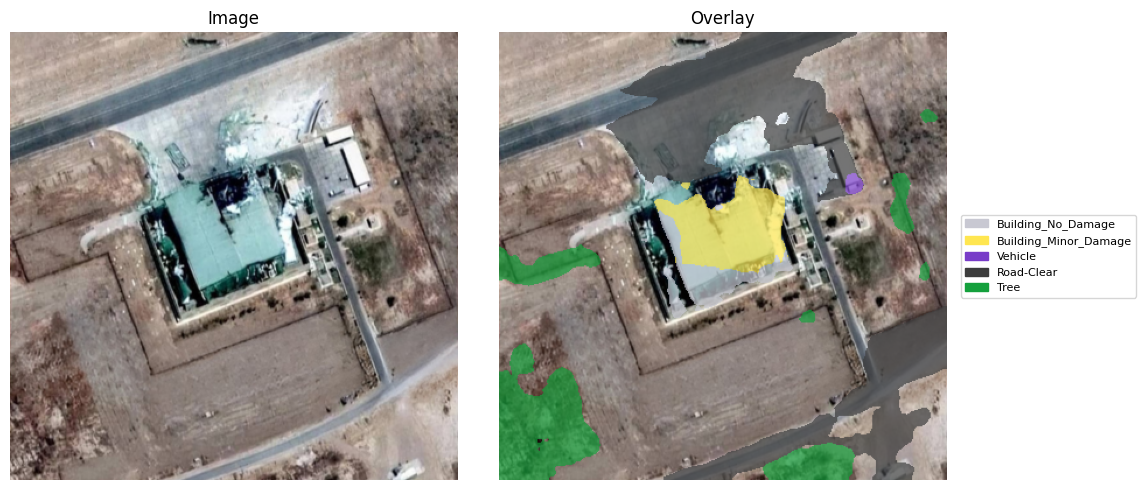

In [10]:
output = inference(model1, image_path)
output = inference(model1, image_path2)


In [26]:
import os
import ipywidgets as widgets
from IPython.display import display, clear_output

def save_uploaded_file(upload_widget, save_dir="uploads"):
    os.makedirs(save_dir, exist_ok=True)

    if not upload_widget.value:
        print("No file uploaded yet.")
        return None

    uploaded_file = upload_widget.value[0]
    filename      = uploaded_file["name"]
    content       = uploaded_file["content"]

    filepath = os.path.join(save_dir, filename)
    with open(filepath, "wb") as f:
        f.write(content)

    return filepath

# --- Usage ---
upload     = widgets.FileUpload(accept='image/*', multiple=False)
btn        = widgets.Button(description="Save & Run")
out        = widgets.Output()

upload_path = None

def on_click(b):
    global upload_path
    with out:
        clear_output()
        upload_path = save_uploaded_file(upload) 
        if upload_path:
            print("Saved at:", upload_path)
            inference(model1, upload_path) 
            # print("Inference output:", output)

btn.on_click(on_click)
display(upload, btn, out)

FileUpload(value=(), accept='image/*', description='Upload')

Button(description='Save & Run', style=ButtonStyle())

Output()